In [29]:
!pip install opendatasets

In [30]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [31]:
df = pd.read_csv('/content/cardekho.csv')

In [32]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [21]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0
8127,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0


In [22]:
df.shape

(8128, 12)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [24]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [25]:
df.isnull().sum().sort_values(ascending=False)

,0
seats,221
mileage(km/ltr/kg),221
engine,221
max_power,215
km_driven,0
selling_price,0
year,0
name,0
owner,0
transmission,0


In [26]:
miss = (df.isnull().sum() / len(df) * 100).round(2)
miss[miss > 0].sort_values(ascending=False)

,0
mileage(km/ltr/kg),2.72
engine,2.72
seats,2.72
max_power,2.65


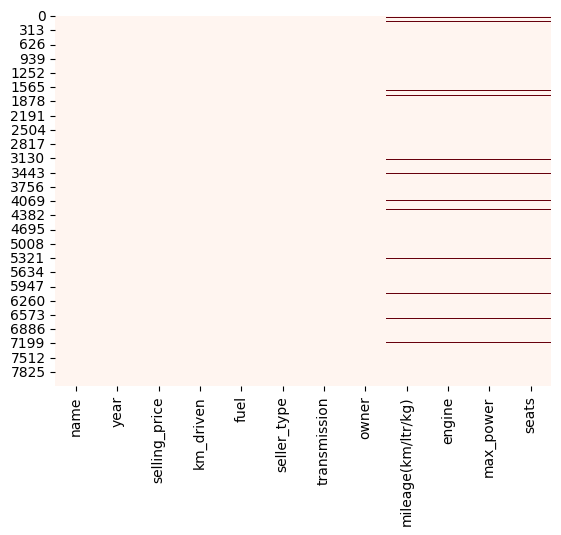

In [27]:
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.show()

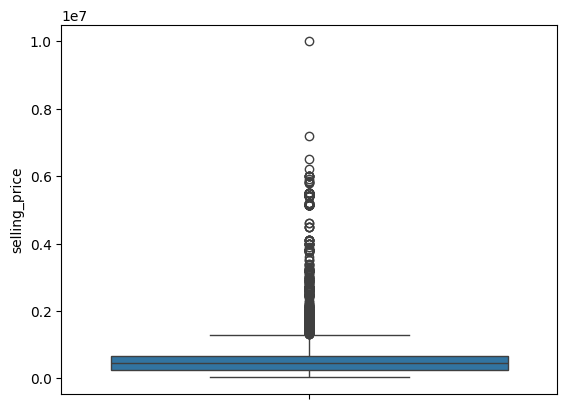

In [33]:
sns.boxplot(data=df, y='selling_price')
plt.show()

In [37]:
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

if 'max_power' in df.columns:
    median = df['max_power'].median()
    df['max_power'].fillna(median, inplace=True)
# bu yerda max_power-dagi bo'sh qiymatlar median qiymat bilan to'ldirildi.

/tmp/ipykernel_1987/1332425335.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['max_power'].fillna(median, inplace=True)


In [38]:
for col in ['mileage(km/ltr/kg)', 'engine', 'seats']:
    if col in df.columns:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
# bu yerda 3 ta ustundagi yo'qolgan qiymatlar median value bilan to'ldirildi.

/tmp/ipykernel_1987/49418530.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [39]:
display(df.isnull().sum().sort_values(ascending=False))
# bunda endi yo'qolgan qiymatlar qolmaganini ko'rishimiz mumkin:) bunda hammasi 0 turibdi.

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),0
engine,0


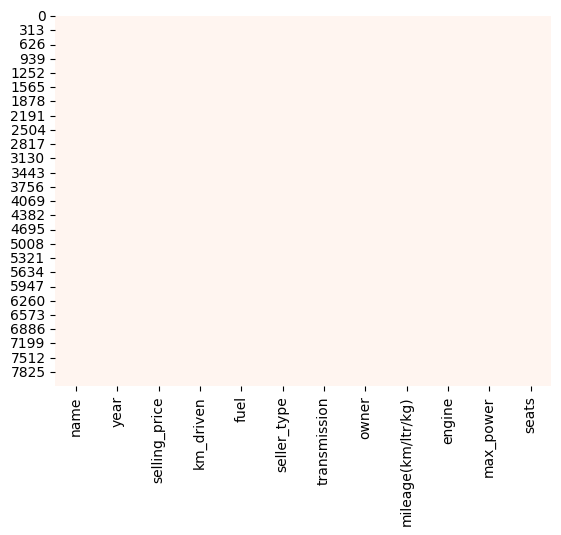

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.show()
# mana bu yerda red chiziqlar qolmaganini ko'rishimiz mumkin.

In [45]:
df.drop_duplicates(inplace=True)
# bunda dublicate qiymatlar o'chirildi.

In [46]:
Q1, Q3 = df['selling_price'].quantile([0.25, 0.75])
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['selling_price'] >= lower) & (df['selling_price'] <= upper)]
# bu yerda outlier qiymatlar o'chirib tashlandi.

'selling_price' ustunidagi chekka qiymatlar olib tashlandi. Dastlabki qatorlar soni: 6926, Yakuniy qatorlar soni: 6598, O'chirilgan qatorlar: 328


In [49]:
df.shape
# oxirgi shape holati, ya'ni tozalangandan keyingi holat.

(6598, 12)

In [50]:
df.describe()
# descibe da:
  # count: bu barcha ustunlar uchun count ni hisoblab beradi.
  # mean: har bir ustunning o'rtacha qiymatini aniqlab beradi.
  # std: bu ustunning standart og'ish qiymati.
  # min: bu ustundagi min qiymat.
  # 25%: Q1 : bu birinchi kvartal, bu qiymatni 25%, bu qiymatdan kichik yoki teng ekanligini ko'rsatadi. yani bu pastgi chegara
  # max: bu ustundagi eng katta qiymatni ko'rsatadi.

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6598.000000,6.598000e+03,6.598000e+03,6598.000000,6598.000000,6598.000000,6598.000000
mean,2013.260988,4.337417e+05,7.530782e+04,19.662414,1385.002273,83.650501,5.396181
std,4.087911,2.500576e+05,5.898717e+04,3.897694,451.936438,25.207451,0.959099
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.385000e+05,4.000000e+04,17.010000,1197.000000,67.100000,5.000000
50%,2014.000000,3.990000e+05,7.000000e+04,19.620000,1248.000000,81.830000,5.000000
75%,2016.000000,6.000000e+05,1.000000e+05,22.540000,1497.000000,94.930000,5.000000
max,2020.000000,1.200000e+06,2.360457e+06,33.440000,3498.000000,272.000000,14.000000
